# Spectral fitting example (NGC 4151): parallel-MEGAlib catalog

This notebook fits NGC 4151 using the parallel-MEGAlib catalog written by
`Source_catalog_generator_comp_parallel_megalib.ipynb`. NGC 4151 must be
present and all catalog
parameters must initially be fixed. The notebook then frees exactly the same
four NGC 4151 parameters for every trial.

Variable-source responses are created only for variable sources that are
actually present in the current catalog. This allows the same fitting notebook
to work for the NGC-4151-only trial and for every cumulative source-addition
trial through the full catalog. Non-repeating source light curves reproduce
the archived cosi-sim fragment boundaries and MEGAlib's independent unit-mean
normalization in every nonzero fragment.


In [10]:
from array import array
import gzip
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astromodels import Cutoff_powerlaw, Parameter, PointSource, Powerlaw, load_model
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import SpecFromDat  # noqa: F401

%matplotlib inline

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [11]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
mock_data_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Mock_Data/Mock_Data_Cut/"
    "mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
background_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
orientation_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"
source_catalog_path = (
    notebook_dir / "source_catalog_DC4_21sources_parallel_megalib.yaml"
)
LIGHTCURVE_NORMALIZATION_MODE = "parallel_megalib"
PARALLEL_SIMULATION_BINS = 1000
# The original DC3 nova run YAML is unavailable. Its archived FITS timing
# profile supports a 500-way run with one normalized active fragment.
PARALLEL_SIMULATION_BINS_BY_SOURCE = {
    "co_nova_continuum": 500,
}
VALID_LIGHTCURVE_NORMALIZATION_MODES = {
    "parallel_megalib",
    "global_megalib",
}
if LIGHTCURVE_NORMALIZATION_MODE not in VALID_LIGHTCURVE_NORMALIZATION_MODES:
    raise ValueError(
        "Unknown light-curve normalization mode: "
        f"{LIGHTCURVE_NORMALIZATION_MODE!r}"
    )
source_library_root = Path(
    "/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library"
)
four_c_21p35_noflare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_noflare/4C_21_lightcurve_noflare.dat"
)
four_c_21p35_flare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_flare/4C_21_lightcurve_flare.dat"
)
maxi_j1820_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1820/MAXIJ1820_LC.dat"
)
maxi_j1348_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1348/MAXIJ1348_LC.dat"
)
three_c_454p3_low_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_low/3C454p3_low_lightcurve.dat"
)
three_c_454p3_high_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_high/3C454p3_high_lightcurve.dat"
)
psr_b1259_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRB1259/PSRB1259_lc.dat"
)
one_rxs_j170849_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/1RXSJ170849/1RXSJ170849_magnetar_lightcurve.dat.gz"
)
generic_magnetar_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/magnetar2/magnetar2_lightcurve.dat.gz"
)
ls_5039_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/LS5039/LS5039_lc.dat"
)
psr_j1846_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRJ1846/J1846_lc.dat"
)
co_nova_continuum_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/nova_co_continuum/nova_co_continuum_lc.dat"
)

# Eight repetitions of the three-month simulation represent 24 months.
# This scales counts and response livetime, not the intrinsic source flux.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier

for path in (
    mock_data_path,
    background_path,
    orientation_path,
    response_path,
    agn_config,
    source_catalog_path,
    four_c_21p35_noflare_lc_path,
    four_c_21p35_flare_lc_path,
    maxi_j1820_lc_path,
    maxi_j1348_lc_path,
    three_c_454p3_low_lc_path,
    three_c_454p3_high_lc_path,
    psr_b1259_lc_path,
    one_rxs_j170849_lc_path,
    generic_magnetar_lc_path,
    ls_5039_lc_path,
    psr_j1846_lc_path,
    co_nova_continuum_lc_path,
):
    if not path.exists():
        raise FileNotFoundError(path)

Apply the 60° orientation/FOV cut for NGC 4151, including Earth occultation. The ordinary filtered 15-second history is used by the background and steady-source responses. For each variable nuisance source, a copy of this same history is weighted interval by interval by its injected light curve after reproducing the source's parallel-MEGAlib normalization.

In [12]:
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ


def load_megalib_lightcurve(lightcurve_path):
    """Read a plain or gzip-compressed MEGAlib DP light-curve table."""
    sample_times = array("d")
    relative_intensities = array("d")
    lightcurve_path = Path(lightcurve_path)
    if lightcurve_path.suffix == ".gz":
        lightcurve_file = gzip.open(lightcurve_path, "rt")
    else:
        lightcurve_file = lightcurve_path.open("rt")

    with lightcurve_file:
        for line in lightcurve_file:
            if line.startswith("DP "):
                _, sample_time, relative_intensity = line.split()
                sample_times.append(float(sample_time))
                relative_intensities.append(float(relative_intensity))

    if len(sample_times) < 2:
        raise ValueError(f"No DP samples found in {lightcurve_path}")

    return (
        np.frombuffer(sample_times, dtype=np.float64),
        np.frombuffer(relative_intensities, dtype=np.float64),
    )


def cosi_sim_lightcurve_slices(n_samples, num_bins):
    """Reproduce make_orientation_bins.py's sample boundaries exactly."""
    samples_per_bin = n_samples // num_bins
    remainder = n_samples % num_bins
    if samples_per_bin < 1:
        raise ValueError("More simulation bins than light-curve samples")

    slices = []
    for bin_index in range(num_bins):
        start = samples_per_bin * bin_index
        stop = start + samples_per_bin + 1
        if stop > n_samples:
            raise ValueError("cosi-sim split extends past the light curve")
        slices.append(slice(start, stop))

    if remainder:
        slices.append(slice(samples_per_bin * num_bins, n_samples))

    interval_coverage = np.zeros(n_samples - 1, dtype=int)
    for chunk_slice in slices:
        interval_coverage[chunk_slice.start : chunk_slice.stop - 1] += 1
    if not np.all(interval_coverage == 1):
        raise RuntimeError("cosi-sim chunks do not cover every interval once")

    return slices


def normalized_lightcurve_profile(
    lightcurve_path,
    repeating=False,
    normalization_mode=LIGHTCURVE_NORMALIZATION_MODE,
    parallel_simulation_bins=PARALLEL_SIMULATION_BINS,
):
    """Return interval endpoint intensities after MEGAlib normalization."""
    sample_times, relative_intensity = load_megalib_lightcurve(lightcurve_path)
    widths = np.diff(sample_times)
    if np.any(widths <= 0) or np.any(relative_intensity < 0):
        raise ValueError(f"Invalid light curve: {lightcurve_path}")

    duration = sample_times[-1] - sample_times[0]
    integral = np.trapezoid(relative_intensity, sample_times)
    if duration <= 0 or integral <= 0:
        raise ValueError(f"Invalid light-curve integral: {lightcurve_path}")

    left_intensity = np.empty(len(sample_times) - 1, dtype=float)
    right_intensity = np.empty(len(sample_times) - 1, dtype=float)

    if repeating or normalization_mode == "global_megalib":
        chunk_slices = [slice(0, len(sample_times))]
        applied_mode = "global_megalib"
    elif normalization_mode == "parallel_megalib":
        chunk_slices = cosi_sim_lightcurve_slices(
            len(sample_times),
            parallel_simulation_bins,
        )
        applied_mode = "parallel_megalib"
    else:
        raise ValueError(f"Unknown normalization mode: {normalization_mode}")

    active_chunks = 0
    active_duration = 0.0
    for chunk_slice in chunk_slices:
        chunk_times = sample_times[chunk_slice]
        chunk_intensity = relative_intensity[chunk_slice]
        chunk_duration = chunk_times[-1] - chunk_times[0]
        chunk_integral = np.trapezoid(chunk_intensity, chunk_times)

        if chunk_duration <= 0:
            raise ValueError(f"Zero-duration light-curve chunk: {lightcurve_path}")
        if chunk_integral > 0:
            scale = chunk_duration / chunk_integral
            active_chunks += 1
            active_duration += chunk_duration
            normalized_integral = np.trapezoid(
                chunk_intensity * scale,
                chunk_times,
            )
            if not np.isclose(
                normalized_integral / chunk_duration,
                1.0,
                rtol=1e-10,
                atol=1e-12,
            ):
                raise RuntimeError("Active chunk does not have unit mean")
        else:
            scale = 0.0

        interval_slice = slice(chunk_slice.start, chunk_slice.stop - 1)
        left_intensity[interval_slice] = chunk_intensity[:-1] * scale
        right_intensity[interval_slice] = chunk_intensity[1:] * scale

    if not (
        np.all(np.isfinite(left_intensity))
        and np.all(np.isfinite(right_intensity))
    ):
        raise RuntimeError(f"Unassigned light-curve intervals: {lightcurve_path}")

    effective_integral = np.sum(
        0.5 * (left_intensity + right_intensity) * widths
    )
    effective_mean = effective_integral / duration
    diagnostics = {
        "normalization mode": applied_mode,
        "repeating": repeating,
        "requested simulation bins": (
            parallel_simulation_bins
            if applied_mode == "parallel_megalib"
            else 1
        ),
        "chunks": len(chunk_slices),
        "active chunks": active_chunks,
        "effective mean": effective_mean,
        "global/parallel factor": 1.0 / effective_mean,
        "active duration (d)": active_duration / 86400.0,
    }
    return sample_times, left_intensity, right_intensity, diagnostics


def lightcurve_interval_weights(
    history,
    lightcurve_path,
    repeating=False,
    parallel_simulation_bins=PARALLEL_SIMULATION_BINS,
):
    """Return normalized mean intensity for every history interval."""
    (
        sample_times,
        left_intensity,
        right_intensity,
        diagnostics,
    ) = normalized_lightcurve_profile(
        lightcurve_path,
        repeating=repeating,
        parallel_simulation_bins=parallel_simulation_bins,
    )
    widths = np.diff(sample_times)
    interval_integrals = 0.5 * (
        left_intensity + right_intensity
    ) * widths
    cumulative = np.concatenate(([0.0], np.cumsum(interval_integrals)))

    def finite_antiderivative(times):
        times = np.asarray(times, dtype=float)
        clipped = np.clip(times, sample_times[0], sample_times[-1])
        indices = np.searchsorted(sample_times, clipped, side="right") - 1
        indices = np.clip(indices, 0, len(sample_times) - 2)
        offsets = clipped - sample_times[indices]
        slopes = (
            right_intensity[indices] - left_intensity[indices]
        ) / widths[indices]
        values = (
            cumulative[indices]
            + left_intensity[indices] * offsets
            + 0.5 * slopes * offsets**2
        )
        values = np.where(times <= sample_times[0], 0.0, values)
        return np.where(times >= sample_times[-1], cumulative[-1], values)

    starts = history.intervals_tstart.unix
    stops = history.intervals_tstop.unix
    interval_durations = stops - starts
    duration = sample_times[-1] - sample_times[0]

    if repeating:
        def antiderivative(times):
            cycles = np.floor((times - sample_times[0]) / duration)
            phases = sample_times[0] + np.mod(
                times - sample_times[0],
                duration,
            )
            return cycles * cumulative[-1] + finite_antiderivative(phases)
    else:
        antiderivative = finite_antiderivative

    weights = (
        antiderivative(stops) - antiderivative(starts)
    ) / interval_durations
    if not np.all(np.isfinite(weights)):
        raise ValueError(f"Non-finite light-curve weights: {lightcurve_path}")
    return np.clip(weights, 0.0, None), diagnostics


def lightcurve_weighted_history(
    history,
    lightcurve_path,
    repeating=False,
    parallel_simulation_bins=PARALLEL_SIMULATION_BINS,
):
    """Multiply interval livetimes by the normalized source intensity."""
    interval_weights, diagnostics = lightcurve_interval_weights(
        history,
        lightcurve_path,
        repeating=repeating,
        parallel_simulation_bins=parallel_simulation_bins,
    )
    weighted_history = SpacecraftHistory(
        history.obstime,
        history.attitude,
        history.location,
        livetime=history.livetime * interval_weights * exposure_multiplier,
    )
    weighted_history.cache_earth_occ = history.cache_earth_occ
    return weighted_history, diagnostics


lightcurve_config = {
    "four_c_21p35_noflare": (four_c_21p35_noflare_lc_path, False),
    "four_c_21p35_flare": (four_c_21p35_flare_lc_path, False),
    "maxi_j1820": (maxi_j1820_lc_path, False),
    "maxi_j1348": (maxi_j1348_lc_path, False),
    "three_c_454p3_low": (three_c_454p3_low_lc_path, False),
    "three_c_454p3_high": (three_c_454p3_high_lc_path, False),
    "psr_b1259": (psr_b1259_lc_path, False),
    "one_rxs_j170849": (one_rxs_j170849_lc_path, True),
    "generic_magnetar": (generic_magnetar_lc_path, True),
    "ls_5039": (ls_5039_lc_path, True),
    "psr_j1846": (psr_j1846_lc_path, True),
    "co_nova_continuum": (co_nova_continuum_lc_path, False),
}
time_dependent_histories = {}
lightcurve_diagnostics = {}
for source_name, (lightcurve_path, repeating) in lightcurve_config.items():
    source_simulation_bins = PARALLEL_SIMULATION_BINS_BY_SOURCE.get(
        source_name,
        PARALLEL_SIMULATION_BINS,
    )
    weighted_history, diagnostics = lightcurve_weighted_history(
        sc_orientation_cut,
        lightcurve_path,
        repeating=repeating,
        parallel_simulation_bins=source_simulation_bins,
    )
    time_dependent_histories[source_name] = weighted_history
    lightcurve_diagnostics[source_name] = diagnostics

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month FOV-cut livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")
print(f"FOV/full livetime fraction: {fov_livetime / full_livetime:.4f}")
print("Light-curve normalization mode:", LIGHTCURVE_NORMALIZATION_MODE)
for source_name, weighted_history in time_dependent_histories.items():
    diagnostics = lightcurve_diagnostics[source_name]
    print(
        f"{source_name}: {diagnostics['normalization mode']}, "
        f"{diagnostics['chunks']} chunks "
        f"({diagnostics['active chunks']} active), "
        f"global/parallel={diagnostics['global/parallel factor']:.3f}, "
        f"weighted livetime={weighted_history.cumulative_livetime()}"
    )

Full orientation livetime: 6,579,555.0 s
Three-month FOV-cut livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s
FOV/full livetime fraction: 0.1490
Light-curve normalization mode: parallel_megalib
four_c_21p35_noflare: parallel_megalib, 1001 chunks (774 active), global/parallel=1.293, weighted livetime=760307.0239947987 s
four_c_21p35_flare: parallel_megalib, 1001 chunks (294 active), global/parallel=3.408, weighted livetime=284231.6005506399 s
maxi_j1820: parallel_megalib, 1001 chunks (651 active), global/parallel=1.539, weighted livetime=635385.0 s
maxi_j1348: parallel_megalib, 1001 chunks (76 active), global/parallel=13.183, weighted livetime=73997.5935288117 s
three_c_454p3_low: parallel_megalib, 1001 chunks (651 active), global/parallel=1.537, weighted livetime=636987.2292486583 s
three_c_454p3_high: parallel_megalib, 1001 chunks (352 active), global/parallel=2.846, weighted livetime=346610.27823240036 s
psr_b1259: parallel_megalib, 1001 chunks (326 active), global/parallel

Load the binned mock data and matching total-background template. `exposure_multiplier` scales the three-month source and background counts to 24 months. It does not change any intrinsic source-spectrum parameters.

In [13]:
mock_data = BinnedData(agn_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}

Open the continuum response.

In [14]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Load the current fixed catalog and create the COSI 3ML plugin. The
default point-source response uses the selected history and its standard
source-visibility treatment. Variable sources receive their source-specific
parallel-MEGAlib or repeating-profile light-curve-weighted responses only when
present.

The YAML preserves the injected polarization of all four Crab components. If
the selected detector response has no `Pol` axis, the notebook explicitly sets
the in-memory polarization degrees to zero and reports that it is using an
unpolarized approximation. Exact polarized folding requires a
polarization-capable response. The 33 ms pulsar profiles average to unit mean
over every 15 s spacecraft interval.


In [15]:
# Load the latest incremental catalog before constructing source responses.
model = load_model(source_catalog_path)
assert len(model.free_parameters) == 0
if "ngc4151" not in model.sources:
    raise RuntimeError("The incremental catalog must always contain ngc4151")

crab_polarization_supported = "Pol" in dr.axes.labels
if "crab" in model.sources and not crab_polarization_supported:
    for component in model.crab.components.values():
        component.polarization.degree.value = 0.0
    print(
        "WARNING: The detector response has no Pol axis. "
        "Using the four-component Crab spectrum with zero polarization."
    )

data = EmCDSBinnedData(data_hist)

bkg = FreeNormBinnedBackground(
    bkg_dist,
    sc_history=sc_orientation,
    copy=False,
)

instrument_response = BinnedInstrumentResponse(dr, data)


def make_point_source_response(spacecraft_history):
    return BinnedThreeMLPointSourceResponse(
        data=data,
        instrument_response=instrument_response,
        sc_history=spacecraft_history,
        energy_axis=dr.axes["Ei"],
        polarization_axis=(
            dr.axes["Pol"] if "Pol" in dr.axes.labels else None
        ),
        nside=2 * data.axes["PsiChi"].nside,
    )


psr = make_point_source_response(sc_orientation)
source_specific_psr = {
    source_name: make_point_source_response(time_dependent_histories[source_name])
    for source_name in model.sources
    if source_name in time_dependent_histories
}
expected_variable_sources = set(model.sources) & set(time_dependent_histories)
assert set(source_specific_psr) == expected_variable_sources

response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
    source_specific_point_source_responses=source_specific_psr,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)

for bkg_label in bkg_dist:
    cosi.bkg_parameter[bkg_label] = Parameter(
        bkg_label,
        1.0,
        min_value=0.0,
        max_value=50.0,
        delta=0.05,
        unit=u.Hz,
    )

print(f"Loaded catalog with {len(model.sources)} entries:")
for source_name in model.sources:
    if source_name == "crab" and crab_polarization_supported:
        response_kind = "four-component polarized"
    elif source_name == "crab":
        response_kind = "four-component unpolarized approximation"
    elif source_name in source_specific_psr:
        response_kind = (
            f"{lightcurve_diagnostics[source_name]['normalization mode']} "
            "light-curve weighted"
        )
    else:
        response_kind = "steady"
    print(f"  {source_name}: {response_kind} response")


Loaded catalog with 21 entries:
  ngc4151: steady response
  crab: four-component unpolarized approximation response
  four_c_21p35_flare: parallel_megalib light-curve weighted response
  maxi_j1820: parallel_megalib light-curve weighted response
  maxi_j1348: parallel_megalib light-curve weighted response
  four_c_71p07: steady response
  four_c_21p35_noflare: parallel_megalib light-curve weighted response
  cena: steady response
  cyg_x1_hard: steady response
  one_e_1740_compow: steady response
  generic_magnetar: global_megalib light-curve weighted response
  psr_b1259: parallel_megalib light-curve weighted response
  grs_1758_258: steady response
  ls_5039: global_megalib light-curve weighted response
  one_rxs_j170849: global_megalib light-curve weighted response
  ngc1068: steady response
  cyg_x3: steady response
  psr_j1846: global_megalib light-curve weighted response
  three_c_454p3_low: parallel_megalib light-curve weighted response
  three_c_454p3_high: parallel_megalib li

Load the fully fixed 19-source catalog, then free the same four NGC 4151 quantities used by the existing hybrid fit: thermal normalization, cutoff energy, tail index, and the linked tail-to-thermal normalization ratio. All other source and spectral parameters remain fixed.

In [16]:
D = 0.30

# Injected spectrum used only for comparison in the plot.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = (
    D * spectrum_inj_cpl.evaluate_at(200.0)
)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# The fixed incremental model was loaded before response construction.
assert len(model.free_parameters) == 0

ngc4151_fit = model.ngc4151.spectrum.main.composite

ngc4151_fit.K_1.min_value = 1e-8
ngc4151_fit.K_1.max_value = 1e-2
ngc4151_fit.K_1.fix = False

ngc4151_fit.xc_1.min_value = 100.0
ngc4151_fit.xc_1.max_value = 20000.0
ngc4151_fit.xc_1.fix = False

ngc4151_fit.index_2.min_value = -5.0
ngc4151_fit.index_2.max_value = 2.0
ngc4151_fit.index_2.fix = False

# K_2 is linked to K_1 in the catalog. Free the link coefficient so the
# tail-to-thermal normalization ratio can be fitted as before.
tail_link = ngc4151_fit.K_2.auxiliary_variable[1]
tail_link.a.fix = True
tail_link.b.fix = False
tail_link.b.min_value = 0.0
tail_link.b.max_value = 1.0
tail_link.b.delta = max(0.1 * tail_link.b.value, 1e-4)
tail_link_ratio = tail_link.b.value

expected_free_parameters = {
    "ngc4151.spectrum.main.composite.K_1",
    "ngc4151.spectrum.main.composite.xc_1",
    "ngc4151.spectrum.main.composite.K_2.Line.b",
    "ngc4151.spectrum.main.composite.index_2",
}
assert set(model.free_parameters) == expected_free_parameters
print("Tail link ratio:", tail_link_ratio)
print("Model sources:", list(model.sources))
print("Free parameters:", list(model.free_parameters))


Tail link ratio: 0.11036383235143271
Model sources: ['ngc4151', 'crab', 'four_c_21p35_flare', 'maxi_j1820', 'maxi_j1348', 'four_c_71p07', 'four_c_21p35_noflare', 'cena', 'cyg_x1_hard', 'one_e_1740_compow', 'generic_magnetar', 'psr_b1259', 'grs_1758_258', 'ls_5039', 'one_rxs_j170849', 'ngc1068', 'cyg_x3', 'psr_j1846', 'three_c_454p3_low', 'three_c_454p3_high', 'co_nova_continuum']
Free parameters: ['ngc4151.spectrum.main.composite.K_1', 'ngc4151.spectrum.main.composite.xc_1', 'ngc4151.spectrum.main.composite.K_2.Line.b', 'ngc4151.spectrum.main.composite.index_2']


### Optional cutoff-power-law-only fit

The next cell is active by default and replaces only NGC 4151's composite
thermal-plus-tail spectrum with a single `Cutoff_powerlaw`. It preserves the
source position, all nuisance sources, and every response defined above. Its
`K`, `index`, and `xc` parameters are fitted while `piv` remains fixed.

To use the original composite fit instead, comment out the entire next code
cell and run the notebook from the top.

In [17]:
# CUTOFF-POWER-LAW OVERRIDE
# Leave this cell active for the CPL-only fit. Comment out the entire cell
# to retain the composite thermal-plus-tail model configured above.
ngc4151_catalog_source = model.ngc4151
ngc4151_catalog_shape = ngc4151_catalog_source.spectrum.main.shape

ngc4151_cpl = Cutoff_powerlaw()
ngc4151_cpl.K.value = ngc4151_catalog_shape.K_1.value
ngc4151_cpl.piv.value = ngc4151_catalog_shape.piv_1.value
ngc4151_cpl.index.value = ngc4151_catalog_shape.index_1.value
ngc4151_cpl.xc.value = ngc4151_catalog_shape.xc_1.value

ngc4151_cpl_source = PointSource(
    "ngc4151",
    l=ngc4151_catalog_source.position.l.value,
    b=ngc4151_catalog_source.position.b.value,
    spectral_shape=ngc4151_cpl,
)
model.remove_source("ngc4151")
model.add_source(ngc4151_cpl_source)

ngc4151_cpl_fit = model.ngc4151.spectrum.main.Cutoff_powerlaw
ngc4151_cpl_fit.K.min_value = 1e-8
ngc4151_cpl_fit.K.max_value = 1e-2
ngc4151_cpl_fit.K.fix = False
ngc4151_cpl_fit.K.delta = 0.1 * ngc4151_cpl_fit.K.value

ngc4151_cpl_fit.piv.fix = True

ngc4151_cpl_fit.index.min_value = -5.0
ngc4151_cpl_fit.index.max_value = 5.0
ngc4151_cpl_fit.index.fix = False
ngc4151_cpl_fit.index.delta = 0.1

ngc4151_cpl_fit.xc.min_value = 100.0
ngc4151_cpl_fit.xc.max_value = 20000.0
ngc4151_cpl_fit.xc.fix = False
ngc4151_cpl_fit.xc.delta = 0.1 * ngc4151_cpl_fit.xc.value

expected_cpl_free_parameters = {
    "ngc4151.spectrum.main.Cutoff_powerlaw.K",
    "ngc4151.spectrum.main.Cutoff_powerlaw.index",
    "ngc4151.spectrum.main.Cutoff_powerlaw.xc",
}
assert set(model.free_parameters) == expected_cpl_free_parameters
print("Active NGC 4151 fit model: Cutoff_powerlaw")
print("Free parameters:", list(model.free_parameters))

00:47:38 WARNING   The following 1 parameters that were linked to source ngc4151                       ]8;id=894045;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=516185;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#527\527]8;;\

         WARNING   have been automatically un-linked: ['ngc4151.spectrum.main.composite.K_2']          ]8;id=599641;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=5287;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#532\532]8;;\

Active NGC 4151 fit model: Cutoff_powerlaw
Free parameters: ['ngc4151.spectrum.main.Cutoff_powerlaw.K', 'ngc4151.spectrum.main.Cutoff_powerlaw.index', 'ngc4151.spectrum.main.Cutoff_powerlaw.xc']


Fit the source model and background normalization once.

In [18]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

00:47:38 INFO      set the minimizer to minuit                                             ]8;id=790319;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=405023;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The occurrence of roundoff error is d

00:49:26 WARNING   48.4 percent of samples have been thrown away because they failed the   ]8;id=734018;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=619171;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

00:49:26 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=731237;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=623413;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=331593;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=681652;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

1.00,-0.89,-0.04,-0.45
-0.89,1.00,-0.14,0.21
-0.04,-0.14,1.00,-0.01
-0.45,0.21,-0.01,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-118228656.20317373
total,-118228656.20317373


Values of statistical measures:

,statistical measures
AIC,-236457304.40617383
BIC,-236457263.01605862


## Error propagation and plotting

Propagate the fitted parameter uncertainties to the NGC 4151 spectrum.

In [19]:
results = like.results
print(results.display())

parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in results.optimized_model["ngc4151"].parameters.values()
    if parameter.free
}
results_err = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **parameters,
)

print(results.optimized_model["ngc4151"])

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.Cutoff_powerlaw.K,(1.48 -0.23 +0.27) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.Cutoff_powerlaw.index,2.51 +/- 0.22,
ngc4151.spectrum.main.Cutoff_powerlaw.xc,(1.000 +/- 0.005) x 10^2,keV
total_bkg,(2.5657 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,-0.89,-0.04,-0.45
-0.89,1.00,-0.14,0.21
-0.04,-0.14,1.00,-0.01
-0.45,0.21,-0.01,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=802192;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=827006;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=941521;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=594216;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=815387;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=245377;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=515323;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=667643;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 1.4793682493579728e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: 2.50918578761

Evaluate the fitted and injected spectra from 200 keV to 5 MeV.

In [20]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()

Plot the fitted and injected SED using the same style as `AGN_Corona_DC4_SubMethod.ipynb`.

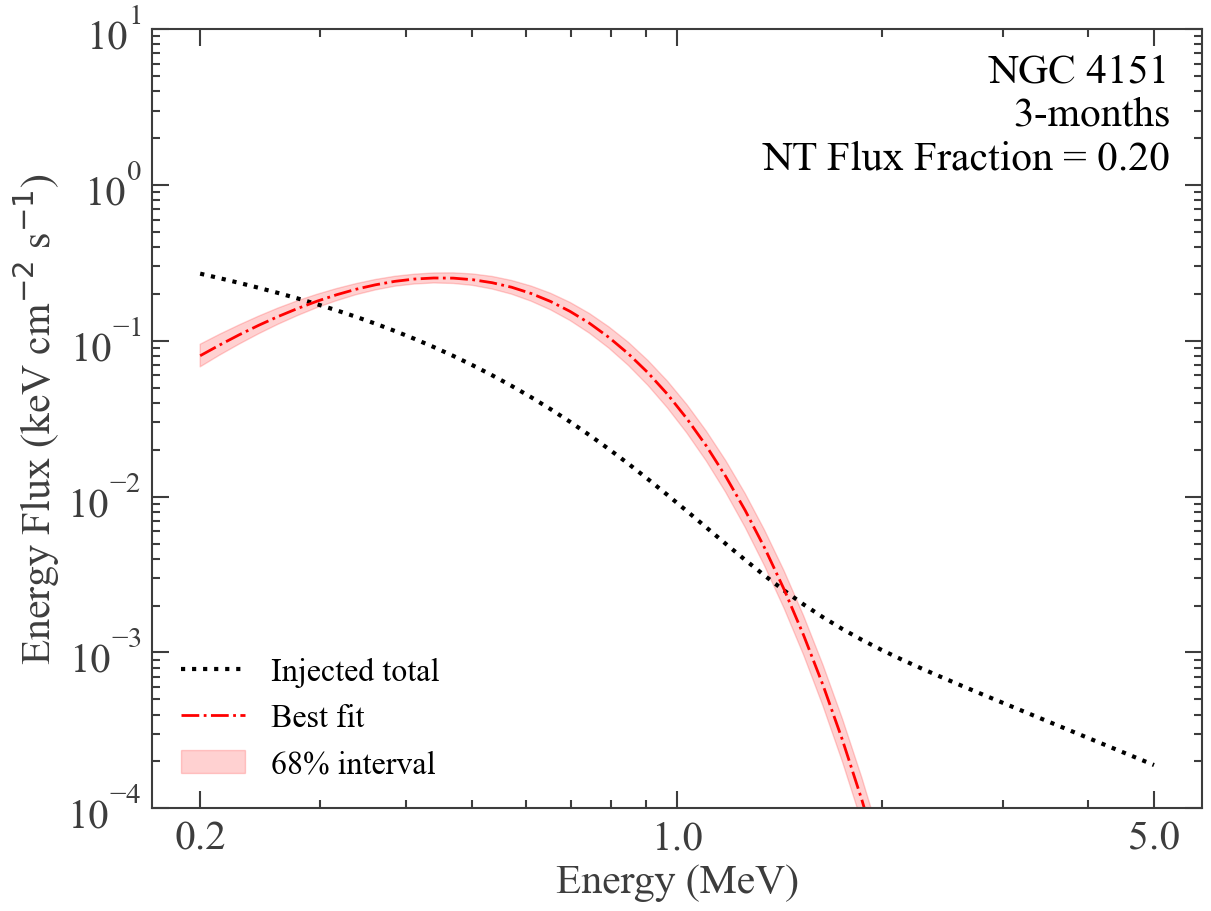

In [21]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    f"NGC 4151\n{exposure_months}-months\nNT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()

Plot the fitted source plus background counts and the observed counts with the same publication-style formatting.

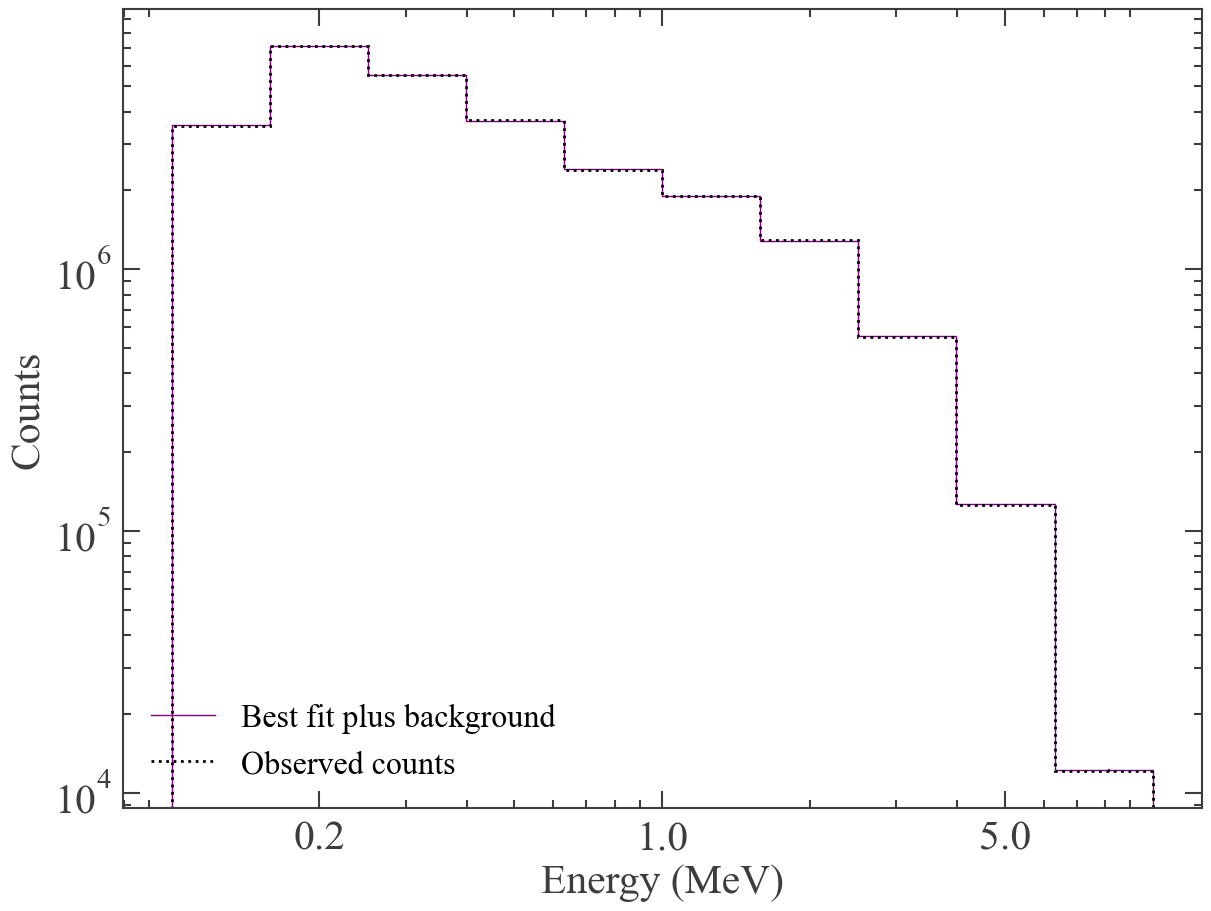

In [22]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()